In [4]:
# NuMI_Flux: post-selection true neutrino energy (MC only, POT-corrected)
# Outputs are saved to ./pdf and ./jpeg as for the other observables.
import os
import sys
workspace_root = os.getcwd()
sys.path.insert(0, workspace_root + "/../../..")
from analysis import Analysis

data_file = '/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/\U0001F3DB PhD Repository/\U0001F680 Research/\U0001F916 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/data/1muNp0pi_Nge1_uncontained.root'


Found NaN category in Sample `mc` with 198 occurrence(s). Masking NaNs...

Processing systematics for sample: mc
Setting weight for mc to 1.00e+00


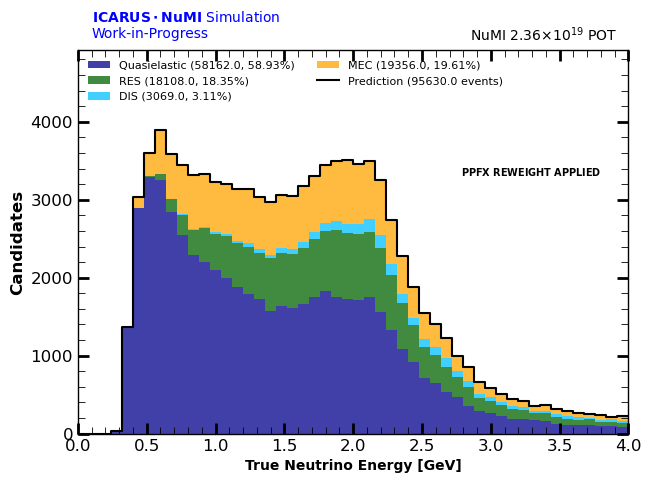

In [7]:
analysis = Analysis('nu_energy.toml', data_file)
analysis.run(close_figs=False)

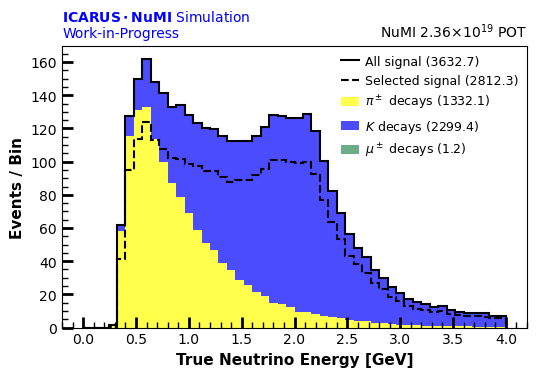

Saved: nu_energy_parent_decomposition


In [8]:
# Parent decomposition of the true neutrino energy spectrum.
# Shows that the double-peak structure exists BEFORE selection and maps onto
# the neutrino parent species (pion decays -> low peak, kaon decays -> ~2 GeV
# peak), and that the selection scales the spectrum without reshaping it.
# Top panel: all true signal events (signal tree) split by parent, with the
# truth-matched selected signal overlaid. Bottom panel: selection efficiency
# vs true neutrino energy.
import uproot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

OUT_DIR = os.getcwd()

ONBEAM_POT, NOMINAL_POT = 2.36124e19, 7.178e20
mc_scale = ONBEAM_POT / NOMINAL_POT
BINS = np.linspace(0, 4, 51)
CENTERS = 0.5 * (BINS[:-1] + BINS[1:])

f = uproot.open(data_file)
sig = f['events/nominal/signal'].arrays(['true_neutrino_energy', 'true_parent_pdg'], library='np')
sel = f['events/nominal/selected'].arrays(['true_neutrino_energy', 'true_parent_pdg', 'true_category'], library='np')

# truth-matched signal events in the selected sample (signal categories)
is_sig = np.isin(sel['true_category'], [0, 1, 3, 4])
e_sel = sel['true_neutrino_energy'][is_sig]

e_all = sig['true_neutrino_energy']
par = np.abs(sig['true_parent_pdg'])

PARENTS = [
    (np.isin(par, [211]),           r'$\pi^\pm$ decays', 'yellow'),
    (np.isin(par, [321, 130, 310]), r'$K$ decays',        'blue'),
    (np.isin(par, [13]),            r'$\mu^\pm$ decays', '#2E8B57'),
]

fig = plt.figure(figsize=(6, 5))
gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.05)
ax = fig.add_subplot(gs[0])
#axr = fig.add_subplot(gs[1], sharex=ax)

bottom = np.zeros(len(CENTERS))
for mask, label, color in PARENTS:
    h, _ = np.histogram(e_all[mask], bins=BINS)
    h = h * mc_scale
    ax.bar(CENTERS, h, width=np.diff(BINS), bottom=bottom, color=color,
           alpha=0.7, label=f'{label} ({h.sum():.1f})')
    bottom += h

h_all, _ = np.histogram(e_all, bins=BINS)
h_all = h_all * mc_scale
h_sel, _ = np.histogram(e_sel, bins=BINS)
h_sel = h_sel * mc_scale
ax.stairs(h_all, BINS, color='black', linewidth=1.5,
          label=f'All signal ({h_all.sum():.1f})')
ax.stairs(h_sel, BINS, color='black', linewidth=1.5, linestyle='--',
          label=f'Selected signal ({h_sel.sum():.1f})')

ax.set_ylabel('Events / Bin', fontsize=11, fontweight='bold', fontfamily='sans-serif')
ax.tick_params(axis='both', which='major', labelsize=10, size=8, width=2, direction='in')
ax.minorticks_on()
ax.tick_params(axis='both', which='minor', size=4, width=1, direction='in')
for lbl in ax.get_xticklabels() + ax.get_yticklabels():
    lbl.set_fontfamily('sans-serif')
# plt.setp(ax.get_xticklabels(), visible=False)  # only when the ratio panel is drawn below
ax.legend(fontsize=9, loc='upper right', ncol=1, framealpha=0.0, edgecolor='none',
          columnspacing=1.0, handlelength=1.4, handletextpad=0.5, borderaxespad=0.3)
ax.text(ax.get_xlim()[0], ax.get_ylim()[1] * 1.02,
        r'$\bf{ICARUS \cdot NuMI}$ Simulation' + '\nWork-in-Progress',
        fontsize=10, color='blue', verticalalignment='bottom', fontfamily='sans-serif')
ax.text(ax.get_xlim()[1], ax.get_ylim()[1] * 1.02,
        f'NuMI {ONBEAM_POT/1e19:.2f}' + r'$\times 10^{19}$ POT',
        fontsize=10, color='black', verticalalignment='bottom', horizontalalignment='right', fontfamily='sans-serif')

with np.errstate(invalid='ignore', divide='ignore'):
    eff = np.where(h_all > 0, h_sel / h_all, np.nan)
ax.set_xlabel('True Neutrino Energy [GeV]', fontsize=11, fontweight='bold', fontfamily='sans-serif')

for sub in ('pdf', 'jpeg'):
    os.makedirs(os.path.join(OUT_DIR, sub), exist_ok=True)
fig.savefig(os.path.join(OUT_DIR, 'pdf/nu_energy_parent_decomposition.pdf'), bbox_inches='tight', dpi=300)
fig.savefig(os.path.join(OUT_DIR, 'jpeg/nu_energy_parent_decomposition.jpeg'), bbox_inches='tight', dpi=300)
plt.show()
print('Saved: nu_energy_parent_decomposition')


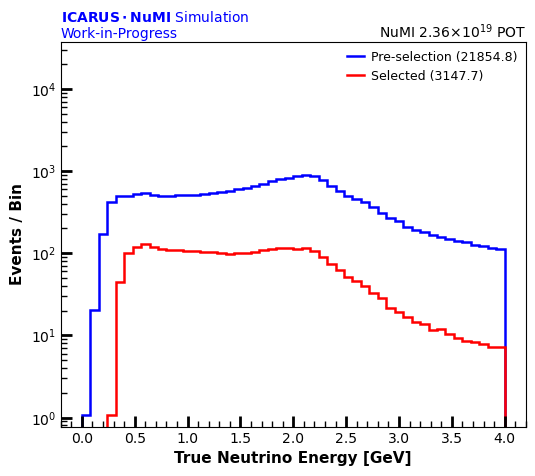

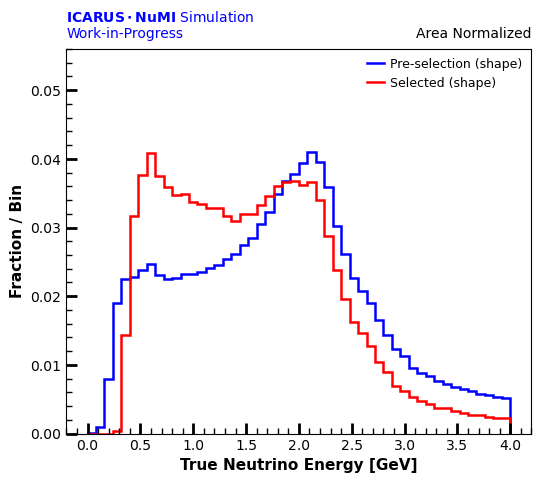

Saved: nu_energy_presel_vs_selected_abs / _shape (pre 21854.8, sel 3147.7)


In [35]:
# Pre-selection vs post-selection true neutrino energy, both POT-normalized
# to the data exposure (2.36124e19 POT). Only entries matched to a true
# neutrino (finite true energy) enter. Two figures, same format as the
# parent decomposition plot: absolute rates (log scale) and area-normalized
# shape comparison.
import uproot
import numpy as np
import matplotlib.pyplot as plt

OUT_DIR = os.getcwd()
ONBEAM_POT, NOMINAL_POT = 2.36124e19, 7.178e20
mc_scale = ONBEAM_POT / NOMINAL_POT
BINS = np.linspace(0, 4, 51)
CENTERS = 0.5 * (BINS[:-1] + BINS[1:])

f = uproot.open(data_file)
e_pre = f['events/nominal/preselection'].arrays(['true_neutrino_energy'], library='np')['true_neutrino_energy']
e_pre = e_pre[np.isfinite(e_pre)]
e_sel = f['events/nominal/selected'].arrays(['true_neutrino_energy'], library='np')['true_neutrino_energy']
e_sel = e_sel[np.isfinite(e_sel)]

h_pre, _ = np.histogram(e_pre, bins=BINS)
h_sel, _ = np.histogram(e_sel, bins=BINS)
h_pre_pot = h_pre * mc_scale
h_sel_pot = h_sel * mc_scale


def style_axes(ax, ylabel, right_label):
    ax.set_ylabel(ylabel, fontsize=11, fontweight='bold', fontfamily='sans-serif')
    ax.set_xlabel('True Neutrino Energy [GeV]', fontsize=11, fontweight='bold', fontfamily='sans-serif')
    ax.tick_params(axis='both', which='major', labelsize=10, size=8, width=2, direction='in')
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', size=4, width=1, direction='in')
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontfamily('sans-serif')
    ax.legend(fontsize=9, loc='upper right', ncol=1, framealpha=0.0, edgecolor='none',
              columnspacing=1.0, handlelength=1.4, handletextpad=0.5, borderaxespad=0.3)
    ax.text(ax.get_xlim()[0], ax.get_ylim()[1] * 1.02,
            r'$\bf{ICARUS \cdot NuMI}$ Simulation' + '\nWork-in-Progress',
            fontsize=10, color='blue', verticalalignment='bottom', fontfamily='sans-serif')
    ax.text(ax.get_xlim()[1], ax.get_ylim()[1] * 1.02,
            right_label,
            fontsize=10, color='black', verticalalignment='bottom',
            horizontalalignment='right', fontfamily='sans-serif')


# --- Figure 1: POT-normalized absolute comparison (log scale) ---
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111)
ax.stairs(h_pre_pot, BINS, color='blue', linewidth=1.8,
          label=f'Pre-selection ({h_pre_pot.sum():.1f})')
ax.stairs(h_sel_pot, BINS, color='red', linewidth=1.8,
          label=f'Selected ({h_sel_pot.sum():.1f})')
ax.set_yscale('log')
ax.set_ylim(ax.get_ylim()[0], ax.get_ylim()[1] * 30)
style_axes(ax, 'Events / Bin', f'NuMI {ONBEAM_POT/1e19:.2f}' + r'$\times 10^{19}$ POT')
fig.savefig(os.path.join(OUT_DIR, 'pdf/nu_energy_presel_vs_selected_abs.pdf'), bbox_inches='tight', dpi=300)
fig.savefig(os.path.join(OUT_DIR, 'jpeg/nu_energy_presel_vs_selected_abs.jpeg'), bbox_inches='tight', dpi=300)
plt.show()

# --- Figure 2: area-normalized shape comparison ---
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111)
ax.stairs(h_pre / max(h_pre.sum(), 1), BINS, color='blue', linewidth=1.8,
          label='Pre-selection (shape)')
ax.stairs(h_sel / max(h_sel.sum(), 1), BINS, color='red', linewidth=1.8,
          label='Selected (shape)')
ax.set_ylim(0, ax.get_ylim()[1] * 1.3)
style_axes(ax, 'Fraction / Bin', 'Area Normalized')
fig.savefig(os.path.join(OUT_DIR, 'pdf/nu_energy_presel_vs_selected_shape.pdf'), bbox_inches='tight', dpi=300)
fig.savefig(os.path.join(OUT_DIR, 'jpeg/nu_energy_presel_vs_selected_shape.jpeg'), bbox_inches='tight', dpi=300)
plt.show()
print(f'Saved: nu_energy_presel_vs_selected_abs / _shape (pre {h_pre_pot.sum():.1f}, sel {h_sel_pot.sum():.1f})')


nu_mu flux:         4.616345e-06 /POT
nu_mu-bar flux:     2.699919e-06 /POT
Total:              7.316264e-06 /POT
For MC POT=7.178e+20: 5.251614e+15 nu/m^2


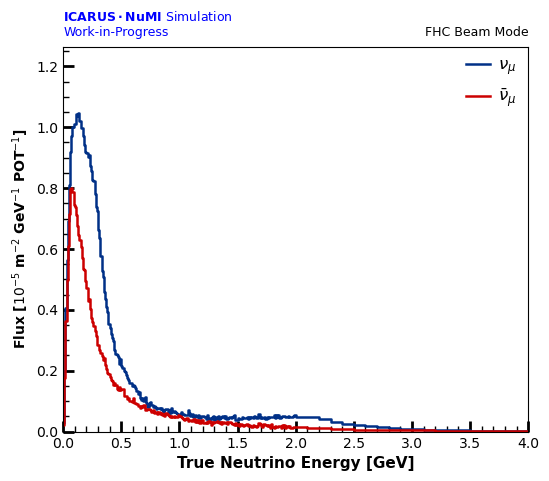

Saved: flux_from_root


In [10]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

# Raw NuMI flux at ICARUS (off-axis, FHC), independent of selection or
# cross section. Contrast with nu_energy_parent_decomposition, which shows
# the SELECTED event rate (flux x cross section x exposure) -- the ~2 GeV
# kaon-decay enhancement visible there is a cross-section effect on top of
# a flux that itself falls off smoothly with no local bump (checked bin by
# bin: flux decreases monotonically past ~1.2 GeV, no second peak).
root_file = "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/\U0001F3DB PhD Repository/\U0001F680 Research/\U0001F916 Experiments&Projects/ICARUS/ICARUS_CC0pi_GUNDAM/data/__ARCHIVE__/uniform_binning.root"
file = uproot.open(root_file)

numu_hist = file["corrected_flux_fhc_numu_BinWidthDivided;1"]
numubar_hist = file["corrected_flux_fhc_numubar_BinWidthDivided;1"]

edges_numu = numu_hist.axis().edges()
values_numu = numu_hist.values()
edges_numubar = numubar_hist.axis().edges()
values_numubar = numubar_hist.values()

bin_widths_numu = np.diff(edges_numu)
bin_widths_numubar = np.diff(edges_numubar)
integrated_flux_numu = np.sum(values_numu * bin_widths_numu)
integrated_flux_numubar = np.sum(values_numubar * bin_widths_numubar)
integrated_flux_total = integrated_flux_numu + integrated_flux_numubar

MC_POT = 7.178e20
total_flux = integrated_flux_total * MC_POT
print(f"nu_mu flux:         {integrated_flux_numu:.6e} /POT")
print(f"nu_mu-bar flux:     {integrated_flux_numubar:.6e} /POT")
print(f"Total:              {integrated_flux_total:.6e} /POT")
print(f"For MC POT={MC_POT:.3e}: {total_flux:.6e} nu/m^2")

# --- ICARUS house style ---
# Rescale by 1e5 so matplotlib doesn't draw a floating "1e-5" offset label
# (which would collide with the ICARUS/beam-mode text above the axes).
SCALE = 1e5
fig, ax = plt.subplots(figsize=(6,5))

ax.step(edges_numu[:-1], values_numu * SCALE, where="post", color="#003087",
        linewidth=1.8, label=r"$\nu_\mu$")
ax.step(edges_numubar[:-1], values_numubar * SCALE, where="post", color="#CC0000",
        linewidth=1.8, label=r"$\bar{\nu}_\mu$")

ax.set_xlim(0, 4)
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
ax.set_xlabel(r"True Neutrino Energy [GeV]", fontsize=11, fontweight="bold",
              fontfamily="sans-serif")
ax.set_ylabel(r"Flux [$10^{-5}$ m$^{-2}$ GeV$^{-1}$ POT$^{-1}$]", fontsize=10,
              fontweight="bold", fontfamily="sans-serif")
ax.tick_params(axis="both", which="major", labelsize=10, size=8, width=2,
               direction="in")
ax.minorticks_on()
ax.tick_params(axis="both", which="minor", size=4, width=1, direction="in")
for lbl in ax.get_xticklabels() + ax.get_yticklabels():
    lbl.set_fontfamily("sans-serif")
ax.legend(fontsize=12, loc="upper right", ncol=1, framealpha=0.0,
          edgecolor="none", columnspacing=1.0, handlelength=1.4,
          handletextpad=0.5, borderaxespad=0.3)
ax.text(0.0, 1.02, r"$\bf{ICARUS \cdot NuMI}$ Simulation" + "\nWork-in-Progress",
        transform=ax.transAxes, fontsize=9, color="blue",
        verticalalignment="bottom", fontfamily="sans-serif", clip_on=False)
ax.text(1.0, 1.02, "FHC Beam Mode",
        transform=ax.transAxes, fontsize=9, color="black",
        verticalalignment="bottom", horizontalalignment="right",
        fontfamily="sans-serif", clip_on=False)

import os
for sub in ("pdf", "jpeg"):
    os.makedirs(sub, exist_ok=True)
fig.savefig("pdf/flux_from_root.pdf", bbox_inches="tight", dpi=300)
fig.savefig("jpeg/flux_from_root.jpeg", bbox_inches="tight", dpi=300)
plt.show()
print("Saved: flux_from_root")


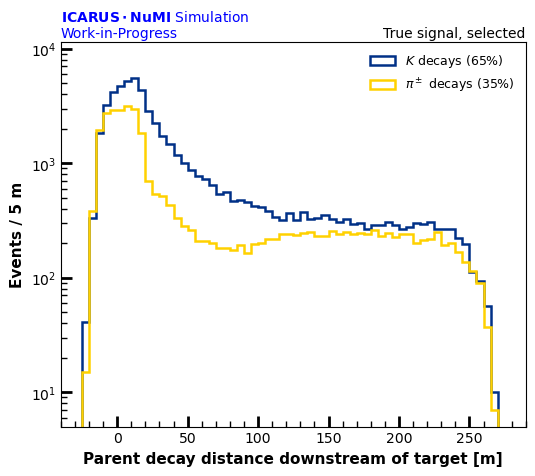

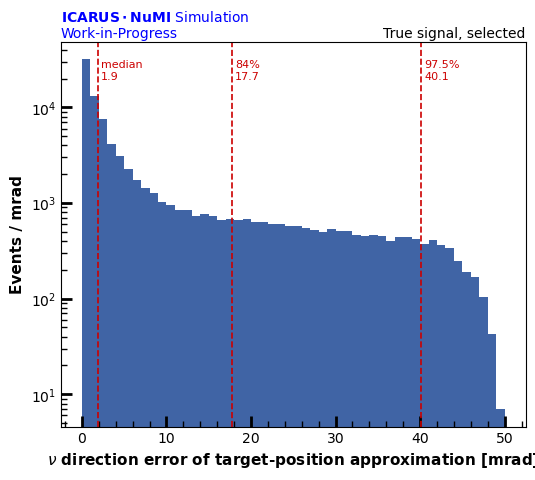

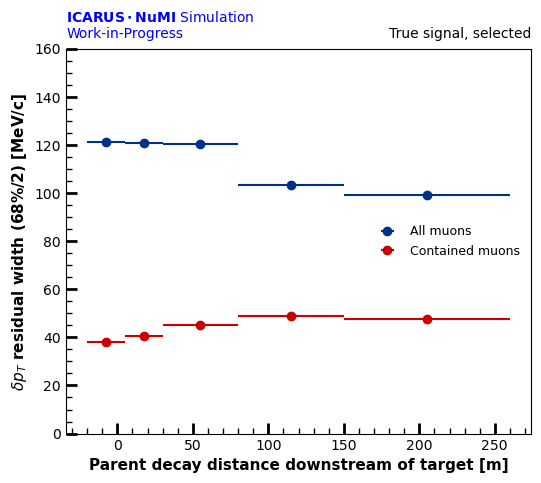

median decay distance: 15.0 m
direction error [mrad] at 50/84/97.5%: [ 1.9 17.7 40.1]
fraction > 10 mrad: 22.9%


In [1]:
# Neutrino production point study -- reviewer question (London):
# "Are we concerned with decays in flight along the NuMI beam at different
# locations, as a neutrino source? I imagine this could cause a significant
# error in the transverse plane definition in some cases."
#
# The nu direction is approximated event-by-event as the unit vector from the
# NuMI target position (31512.0380, 3364.4912, 73363.2532) cm to the vertex.
# The true production point sits a distance d = |V - T| - true_baseline
# downstream of the target; the direction error of the approximation is
# dtheta ~ arcsin(d sin(alpha)/baseline) with alpha ~ 5.7 deg the ICARUS
# off-axis angle. Because ICARUS is off-axis, parents that reach us decay
# dominantly near the target (Howard); this cell quantifies the tail and its
# impact on the dpT residual.

import os
import uproot
import numpy as np
import matplotlib.pyplot as plt

NAVY, GOLD, RED, GREEN = "#003087", "#FFD100", "#CC0000", "#2E8B57"
SYST_FILE = (
    "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/"
    "My Drive/\U0001F3DB PhD Repository/\U0001F680 Research/\U0001F916 Experiments&Projects/"
    "ICARUS/ICARUS_CC0pi_Selection/data/icarus_numi_numu_mc_onbeam_offbeam_syst_ppfx.root"
)
TARGET = np.array([31512.0380, 3364.4912, 73363.2532])  # cm, detector coords
OFFAXIS_DEG = 5.7

t = uproot.open(SYST_FILE)["events/full/selected"]
a = t.arrays(["true_category", "true_baseline", "true_vertex_x", "true_vertex_y",
              "true_vertex_z", "true_parent_pdg", "reco_dpT_lp",
              "true_dpT_lp_genie", "reco_leading_muon_containment"], library="np")
sig = np.isin(a["true_category"], [0, 1, 3, 4])
V = np.vstack([a["true_vertex_x"], a["true_vertex_y"], a["true_vertex_z"]]).T
L = np.linalg.norm(V - TARGET, axis=1) / 100.0   # target -> vertex [m]
b = a["true_baseline"].astype(float)             # decay point -> vertex [m]
d = L - b                                        # decay distance downstream of target [m]
dtheta = np.arcsin(np.clip(np.maximum(d, 0) * np.sin(np.deg2rad(OFFAXIS_DEG)) / b, 0, 1)) * 1000
par = np.abs(a["true_parent_pdg"])
res = a["reco_dpT_lp"] - a["true_dpT_lp_genie"]
cont = a["reco_leading_muon_containment"] == 1

OUT_DIR = os.getcwd()
os.makedirs(os.path.join(OUT_DIR, "pdf"), exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "jpeg"), exist_ok=True)

def style(ax, xl, yl, right):
    ax.set_xlabel(xl, fontsize=11, fontweight="bold", fontfamily="sans-serif")
    ax.set_ylabel(yl, fontsize=11, fontweight="bold", fontfamily="sans-serif")
    ax.tick_params(axis="both", which="major", labelsize=10, size=8, width=2, direction="in")
    ax.minorticks_on()
    ax.tick_params(axis="both", which="minor", size=4, width=1, direction="in")
    for l in ax.get_xticklabels() + ax.get_yticklabels():
        l.set_fontfamily("sans-serif")
    ax.text(ax.get_xlim()[0], ax.get_ylim()[1] * 1.02,
            r"$\bf{ICARUS \cdot NuMI}$ Simulation" + "\nWork-in-Progress",
            fontsize=10, color="blue", va="bottom", fontfamily="sans-serif")
    ax.text(ax.get_xlim()[1], ax.get_ylim()[1] * 1.02, right,
            fontsize=10, color="black", va="bottom", ha="right", fontfamily="sans-serif")

# --- A) decay distance by parent species ---
fig, ax = plt.subplots(figsize=(6, 5))
BINS = np.linspace(-25, 275, 61)
for mask, lab, c in [(np.isin(par, [321, 130, 310]), r"$K$ decays", NAVY),
                     (np.isin(par, [211]), r"$\pi^\pm$ decays", GOLD)]:
    m = sig & mask
    ax.hist(d[m], bins=BINS, histtype="step", linewidth=1.8, color=c,
            label=f"{lab} ({100 * m.sum() / sig.sum():.0f}%)")
ax.set_yscale("log")
ax.legend(fontsize=9, loc="upper right", framealpha=0.0, edgecolor="none")
ax.set_ylim(ax.get_ylim()[0], ax.get_ylim()[1] * 1.5)
style(ax, "Parent decay distance downstream of target [m]", "Events / 5 m",
      r"True signal, selected")
fig.savefig(os.path.join(OUT_DIR, "pdf/numi_decay_distance_by_parent.pdf"),
            bbox_inches="tight", dpi=300)
fig.savefig(os.path.join(OUT_DIR, "jpeg/numi_decay_distance_by_parent.jpeg"),
            bbox_inches="tight", dpi=300)
plt.show()

# --- B) implied direction error of the target-position approximation ---
fig, ax = plt.subplots(figsize=(6, 5))
ax.hist(dtheta[sig], bins=np.linspace(0, 50, 51), histtype="stepfilled",
        color=NAVY, alpha=0.75)
ax.set_yscale("log")
q = np.percentile(dtheta[sig], [50, 84, 97.5])
for v, lab in zip(q, ["median", "84%", "97.5%"]):
    ax.axvline(v, color=RED, ls="--", lw=1.2)
    ax.text(v + 0.4, ax.get_ylim()[1] * 0.4, f"{lab}\n{v:.1f}", fontsize=8, color=RED)
style(ax, r"$\nu$ direction error of target-position approximation [mrad]",
      "Events / mrad", r"True signal, selected")
fig.savefig(os.path.join(OUT_DIR, "pdf/numi_direction_error_mrad.pdf"),
            bbox_inches="tight", dpi=300)
fig.savefig(os.path.join(OUT_DIR, "jpeg/numi_direction_error_mrad.jpeg"),
            bbox_inches="tight", dpi=300)
plt.show()

# --- C) dpT residual width vs decay distance ---
edges = np.array([-20., 5., 30., 80., 150., 260.])
centers = 0.5 * (edges[:-1] + edges[1:])
half = 0.5 * np.diff(edges)
fig, ax = plt.subplots(figsize=(6, 5))
for msel, lab, c in [(sig, "All muons", NAVY), (sig & cont, "Contained muons", RED)]:
    w = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = msel & (d >= lo) & (d < hi)
        q16, q84 = np.percentile(res[m], [15.865, 84.135])
        w.append(0.5 * (q84 - q16))
    ax.errorbar(centers, w, xerr=half, fmt="o", color=c, label=lab)
ax.set_ylim(0, 160)
ax.legend(fontsize=9, loc="center right", framealpha=0.0, edgecolor="none")
style(ax, "Parent decay distance downstream of target [m]",
      r"$\delta p_T$ residual width (68%/2) [MeV/c]", r"True signal, selected")
fig.savefig(os.path.join(OUT_DIR, "pdf/dpT_residual_width_vs_decay_distance.pdf"),
            bbox_inches="tight", dpi=300)
fig.savefig(os.path.join(OUT_DIR, "jpeg/dpT_residual_width_vs_decay_distance.jpeg"),
            bbox_inches="tight", dpi=300)
plt.show()

print(f"median decay distance: {np.median(d[sig]):.1f} m")
print(f"direction error [mrad] at 50/84/97.5%: {q.round(1)}")
print(f"fraction > 10 mrad: {100 * (dtheta[sig] > 10).mean():.1f}%")
